In [230]:
import os
import pandas as pd
import glob
import SimpleITK as sitk

In [231]:
path_to_folder = "/scratch/p302386/dataLongitudinal/"
path_to_file = "/scratch/p302386/experimentsLongitudinal/outcomes.xlsx"

In [232]:
file_outcomes = pd.read_excel(path_to_file)

In [233]:
patients_two_weeks = file_outcomes[file_outcomes["two_weeks"]==1]["PatientID"].values
patients_three_weeks = file_outcomes[file_outcomes["three_weeks"]==1]["PatientID"].values
patients_four_weeks = file_outcomes[file_outcomes["four_weeks"]==1]["PatientID"].values

In [234]:
#patients = os.listdir(path_to_folder)

In [235]:
def calculate_number_fractions(patient_list, number):
    lengths = list()
    for p in patient_list:
        all_fractions = glob.glob(path_to_folder+p+"/*_fr*")
        numbers = [int(l.split("fr_")[-1].split("_")[0]) for l in all_fractions]
        numbers.sort()
        if len(numbers)!=len(list(set(numbers))):
            print("Problem with patient " + p)
        lengths.append(numbers[:number])
    return zip(patient_list,lengths)

In [236]:
import matplotlib.pyplot as plt

def calculate_differences_within_lists(lst):
    """Calculate the differences between consecutive numbers within each sublist."""
    differences=list()
    patients=list()
    
    for (p, lista) in lst:
        print(f"{p}:{[lista[i+1] - lista[i] for i in range(len(lista)-1)]}")
        differences.append([lista[i+1] - lista[i] for i in range(len(lista)-1)])
        patients.append(p)
    
    return patients, differences 

def plot_histogram(data):
    """Plot a histogram of the given data."""
    plt.hist(data, bins=20, color='skyblue', edgecolor='black')
    plt.xlabel('Difference')
    plt.ylabel('Frequency')
    plt.title('Histogram of Differences within Sublists')
    plt.show()

UMCG-0020715:[5]
UMCG-0021879:[5]
UMCG-0059896:[5]
UMCG-0070426:[5]
UMCG-0170637:[7]
UMCG-0191693:[5]
UMCG-0263964:[8]
UMCG-0276627:[5]
UMCG-0287554:[5]
UMCG-0287744:[5]
UMCG-0298536:[6]
UMCG-0303865:[5]
UMCG-0345451:[6]
UMCG-0412861:[4]
UMCG-0573601:[5]
UMCG-0587984:[5]
UMCG-0598217:[5]
UMCG-0611128:[5]
UMCG-0701196:[5]
UMCG-0838551:[4]
UMCG-0861452:[5]
UMCG-0872458:[5]
UMCG-0885661:[6]
UMCG-0903246:[7]
UMCG-0938572:[4]
UMCG-0940338:[4]
UMCG-0946689:[4]
UMCG-0970348:[5]
UMCG-1051551:[7]
UMCG-1097433:[6]
UMCG-1117043:[5]
UMCG-1124041:[7]
UMCG-1165250:[6]
UMCG-1173908:[4]
UMCG-1191508:[4]
UMCG-1214381:[4]
UMCG-1318845:[5]
UMCG-1320820:[5]
UMCG-1375386:[6]
UMCG-1434975:[5]
UMCG-1474145:[5]
UMCG-1479802:[5]
UMCG-1737477:[6]
UMCG-1973344:[8]
UMCG-2000655:[6]
UMCG-2002365:[4]
UMCG-2016613:[5]
UMCG-2022769:[6]
UMCG-2022790:[3]
UMCG-2024557:[5]
UMCG-2027942:[5]
UMCG-2038542:[6]
UMCG-2051341:[5]
UMCG-2075963:[4]
UMCG-2076094:[4]
UMCG-2078256:[5]
UMCG-2080097:[3]
UMCG-2083033:[5]
UMCG-2087361:[

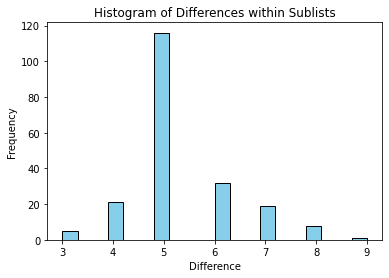

In [238]:
fractions_2weeks = calculate_number_fractions(patients_two_weeks, 2)
patients_w2, fract_diff_w2 = calculate_differences_within_lists(fractions_2weeks)

flattened_differences = [item for row in fract_diff_w2 for item in row]

# Plot the histogram of differences within sublists
plot_histogram(flattened_differences)

UMCG-0020715:[5, 5]
UMCG-0021879:[5, 5]
UMCG-0059896:[5, 5]
UMCG-0070426:[5, 5]
UMCG-0191693:[5, 5]
UMCG-0276627:[5, 5]
UMCG-0287554:[5, 5]
UMCG-0287744:[5, 5]
UMCG-0298536:[6, 6]
UMCG-0303865:[5, 5]
UMCG-0345451:[6, 5]
UMCG-0412861:[4, 6]
UMCG-0573601:[5, 6]
UMCG-0587984:[5, 5]
UMCG-0598217:[5, 5]
UMCG-0611128:[5, 5]
UMCG-0701196:[5, 5]
UMCG-0838551:[4, 6]
UMCG-0861452:[5, 5]
UMCG-0872458:[5, 5]
UMCG-0885661:[6, 6]
UMCG-0903246:[7, 5]
UMCG-0938572:[4, 6]
UMCG-0940338:[4, 6]
UMCG-0946689:[4, 5]
UMCG-0970348:[5, 5]
UMCG-1051551:[7, 5]
UMCG-1097433:[6, 5]
UMCG-1117043:[5, 5]
UMCG-1124041:[7, 5]
UMCG-1165250:[6, 6]
UMCG-1191508:[4, 6]
UMCG-1214381:[4, 6]
UMCG-1318845:[5, 5]
UMCG-1320820:[5, 5]
UMCG-1375386:[6, 6]
UMCG-1434975:[5, 5]
UMCG-1474145:[5, 7]
UMCG-1479802:[5, 4]
UMCG-1737477:[6, 6]
UMCG-2000655:[6, 6]
UMCG-2002365:[4, 5]
UMCG-2016613:[5, 5]
UMCG-2022769:[6, 4]
UMCG-2022790:[3, 7]
UMCG-2024557:[5, 4]
UMCG-2027942:[5, 5]
UMCG-2051341:[5, 6]
UMCG-2075963:[4, 4]
UMCG-2076094:[4, 5]


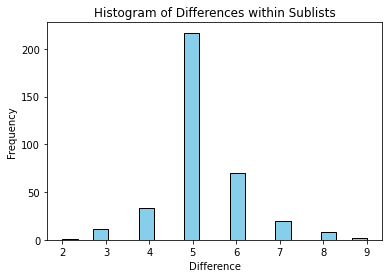

In [237]:
fractions_3weeks = calculate_number_fractions(patients_three_weeks, 3)
patients_w3, fract_diff_w3 = calculate_differences_within_lists(fractions_3weeks)

flattened_differences = [item for row in fract_diff_w3 for item in row]

# Plot the histogram of differences within sublists
plot_histogram(flattened_differences)

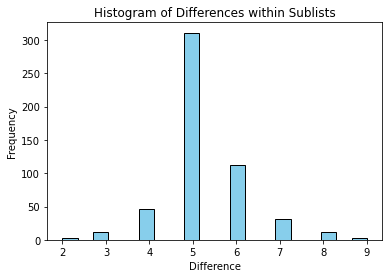

In [227]:
fractions_4weeks = calculate_number_fractions(patients_four_weeks, 4)
patients_w4, fract_diff_w4 = calculate_differences_within_lists(fractions_4weeks)

flattened_differences = [item for row in fract_diff_w4 for item in row]

# Plot the histogram of differences within sublists
plot_histogram(flattened_differences)

In [228]:
fract_diff_w4

[[5, 5, 5],
 [5, 5, 5],
 [5, 5, 5],
 [5, 5, 5],
 [5, 5, 5],
 [5, 5, 5],
 [5, 5, 5],
 [5, 5, 6],
 [6, 6, 6],
 [5, 5, 5],
 [6, 5, 6],
 [4, 6, 6],
 [5, 6, 4],
 [5, 5, 5],
 [5, 5, 5],
 [5, 5, 5],
 [5, 5, 5],
 [4, 6, 5],
 [5, 5, 5],
 [5, 5, 5],
 [6, 6, 6],
 [7, 5, 6],
 [4, 6, 4],
 [4, 6, 5],
 [4, 5, 5],
 [5, 5, 5],
 [7, 5, 5],
 [6, 5, 7],
 [5, 5, 7],
 [7, 5, 7],
 [6, 6, 6],
 [4, 6, 5],
 [4, 6, 4],
 [5, 5, 5],
 [5, 5, 5],
 [6, 6, 6],
 [5, 5, 5],
 [5, 7, 7],
 [5, 4, 6],
 [6, 6, 6],
 [6, 6, 6],
 [4, 5, 6],
 [5, 5, 5],
 [6, 4, 5],
 [3, 7, 6],
 [5, 4, 5],
 [5, 5, 5],
 [5, 6, 4],
 [4, 4, 5],
 [4, 5, 7],
 [5, 5, 5],
 [3, 5, 6],
 [5, 5, 5],
 [5, 5, 5],
 [5, 5, 5],
 [5, 5, 5],
 [4, 4, 4],
 [5, 5, 5],
 [5, 5, 5],
 [5, 6, 3],
 [6, 5, 5],
 [3, 9, 6],
 [5, 5, 5],
 [5, 5, 5],
 [7, 2, 7],
 [5, 3, 6],
 [6, 6, 6],
 [6, 5, 5],
 [4, 6, 4],
 [5, 5, 5],
 [5, 6, 6],
 [6, 4, 5],
 [5, 4, 6],
 [5, 5, 5],
 [5, 5, 5],
 [5, 5, 5],
 [5, 8, 6],
 [5, 6, 6],
 [8, 5, 5],
 [5, 3, 8],
 [5, 5, 5],
 [5, 8, 4],
 [7, 4, 6],
 [5,